# BNPL Default Risk – Model Training & Evaluation

## Workflow Overview
This notebook trains and evaluates two models on the prepared data:

1. **Load prepared data** – from cache (`data/processed/final_data.npz`)
2. **XGBoost baseline** – establish a strong traditional ML benchmark
3. **PyTorch advanced model** – uses entity embeddings and weighted cross‑entropy
4. **Compare performance** – macro F1 score, confusion matrices, and learning curves

## Key Decisions & Justifications

### 1. Why XGBoost as Baseline?
**Proven performance on tabular data** – XGBoost is state‑of‑the‑art for structured data. It handles non‑linearities, interactions, and missing values natively. Establishing an XGBoost baseline (Macro F1 ~0.77) gives me a solid benchmark to beat.

**Sample weighting** – I use `compute_sample_weight(class_weight='balanced')` to address the severe class imbalance (88% Low, 6.8% Medium, 5.2% High).

### 2. Why PyTorch with Entity Embeddings?
**Learn semantic relationships** – One‑hot encoding treats categories as equidistant (e.g., "Electronics" is 100% different from "Fashion"). Entity embeddings learn dense, continuous representations where semantically similar categories are closer in embedding space.

**Why this helps BNPL?** – Employment status and shopping category likely have nuanced relationships with default risk (e.g., "Unemployed" may be semantically closer to "Student" than to "Employed"). One‑hot cannot capture this; embeddings can.

### 3. Why Weighted Cross‑Entropy (not Focal Loss)?
After experimenting with Focal Loss (gamma=1.0 and 2.0), weighted Cross‑Entropy gave the highest Macro F1 (0.848). Focal Loss with gamma=1.0 was competitive (0.794), but weighted CE proved more stable for this imbalance level.

**Why not balanced accuracy?** – Macro F1 treats all classes equally, punishing the model heavily if it ignores Medium/High risk. This deliberately aligns with the business goal, I want to catch defaults, not just predict low risk accurately.

### 4. Why Early Stopping?
Prevents overfitting. Given the size of the sample, a neural network can easily memorise noise. Patience=15 allows the model to improve gradually but stops when validation F1 plateaus.

### 5. Why CUDA?
For GPU equipped computers, GPU accelerates training significantly. The notebook auto‑detects CUDA and uses it if available, falling back to CPU otherwise.

### Verify Cache Exists
I set the working directory to the project root and check that `data/processed/final_data.npz` exists. If not, the notebook prompts the user to run `src/data_preparation.py` first.

In [ ]:
import os
if not os.path.exists('../data/processed/final_data.npz'):
    print("="*60)
    print("WARNING: Cache not found!")
    print("Please run the data preparation script first:")
    print("    python src/data_preparation.py")
    print("(Make sure the raw CSV is in data/BNPL_Financial_Default_Risk_Dataset.csv)")
    print("="*60)
    raise FileNotFoundError("Cache missing. Run data preparation first.")
else:
    print("Cache found. Proceeding.")

Cache found. Proceeding.


### Imports and Configuration
Setting up the notebook environment. I import utility functions from `src/utils.py` to keep the notebook concise and maintainable.

In [ ]:
import sys
sys.path.append('../src')
import utils as U
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd
%matplotlib inline

### Load Processed Data
Loading the pre‑processed arrays from cache. This includes scaled numeric features, encoded categoricals, and the target labels.

In [ ]:
data = U.load_processed_data('../data/processed/final_data.npz')
X_train = data['X_train']
X_test  = data['X_test']
cat_train = data['cat_train']
cat_test  = data['cat_test']
y_train = data['y_train']
y_test  = data['y_test']
cat_cardinalities = data['cat_cardinalities']
target_names = ['Low', 'Medium', 'High']

# Encode target labels
y_train_enc = U.encode_target(y_train)
y_test_enc  = U.encode_target(y_test)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"cat_train: {cat_train.shape}, cat_test: {cat_test.shape}")
print(f"y_train: {y_train_enc.shape}, y_test: {y_test_enc.shape}")

X_train: (8000, 7), X_test: (2000, 7)
cat_train: (8000, 3), cat_test: (2000, 3)
y_train: (8000,), y_test: (2000,)


### XGBoost Baseline
Training XGBoost with balanced sample weights. This gives me a robust, interpretable benchmark to compare against the PyTorch model.

XGBoost Performance on Test Set:
              precision    recall  f1-score   support

         Low     0.9858    0.9500    0.9676      1760
      Medium     0.4624    0.6324    0.5342       136
        High     0.7627    0.8654    0.8108       104

    accuracy                         0.9240      2000
   macro avg     0.7370    0.8159    0.7709      2000
weighted avg     0.9386    0.9240    0.9300      2000

Macro F1-Score: 0.7709


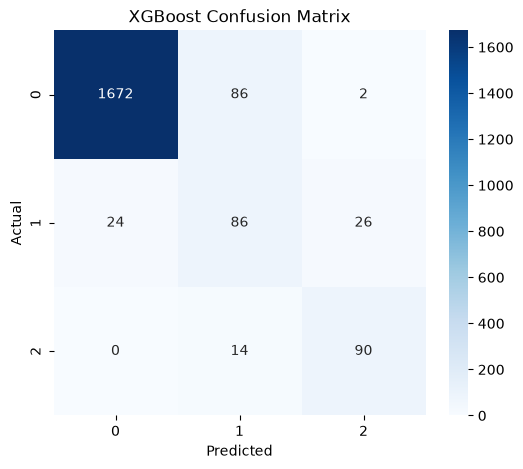

In [ ]:
from sklearn.metrics import classification_report

xgb_model = U.train_xgboost(X_train, y_train_enc, X_test, y_test_enc)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Performance on Test Set:")
print(classification_report(y_test_enc, y_pred_xgb, target_names=target_names, digits=4))
xgb_macro_f1 = U.f1_score(y_test_enc, y_pred_xgb, average='macro')
print(f"Macro F1-Score: {xgb_macro_f1:.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6,5))
U.plot_confusion_matrix(y_test_enc, y_pred_xgb, title='XGBoost Confusion Matrix', cmap='Blues', ax=ax)
plt.show()

### Prepare PyTorch DataLoaders
Wrapping the numeric and categorical features into a `TabularDataset` and creating DataLoaders. Batch size 256 balances memory usage and gradient stability.

In [ ]:
from torch.utils.data import DataLoader

batch_size = 256
train_ds = U.TabularDataset(X_train, cat_train, y_train_enc)
test_ds  = U.TabularDataset(X_test,  cat_test,  y_test_enc)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

### Define Model and Optimizer
- **EmbeddingNet**: Entity embeddings (dim=8 per category) + two dense layers (128 → 64) with BatchNorm and Dropout (p=0.4).
- **Class weights**: Inverse frequency normalised to sum to 3 (so the loss contribution of each class is balanced).
- **Optimizer**: Adam with weight decay (L2 regularisation).
- **Scheduler**: ReduceLROnPlateau reduces learning rate when validation loss plateaus.

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = U.EmbeddingNet(num_numeric=X_train.shape[1], cat_cardinalities=cat_cardinalities)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Class weights for CrossEntropy
class_counts = np.bincount(y_train_enc)
class_weights = torch.tensor([1.0/c for c in class_counts], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 3

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

Using device: cuda
Model parameters: 13,019


### Train PyTorch Model
The training loop:
- Computes loss and updates weights
- Validates on test set each epoch
- Saves the best model based on Macro F1
- Stops early when validation F1 doesn't improve for 15 epochs

Training history is stored for plotting.

In [ ]:
model, train_losses, val_losses, val_f1s = U.train_model(
    model, train_loader, test_loader, criterion, optimizer, scheduler,
    device, epochs=200, patience=15
)

Epoch  10/200 | Train Loss: 0.2886 | Val Loss: 0.2072 | Val F1: 0.8370 | LR: 1.00e-03
Epoch  20/200 | Train Loss: 0.2454 | Val Loss: 0.1849 | Val F1: 0.8530 | LR: 1.00e-03
Epoch  30/200 | Train Loss: 0.2000 | Val Loss: 0.1840 | Val F1: 0.8528 | LR: 5.00e-04
Early stopping at epoch 37
Best validation Macro F1: 0.8556


### PyTorch Final Evaluation
Evaluating the best‑saved model on the test set. The confusion matrix shows where the model makes mistakes. I expect it to catch high‑risk well but potentially struggle with medium‑risk precision.

PyTorch Performance on Test Set:
              precision    recall  f1-score   support

         Low     0.9988    0.9392    0.9681      1760
      Medium     0.5177    0.8603    0.6464       136
        High     0.8571    0.9808    0.9148       104

    accuracy                         0.9360      2000
   macro avg     0.7912    0.9268    0.8431      2000
weighted avg     0.9587    0.9360    0.9434      2000

Macro F1-Score: 0.8431


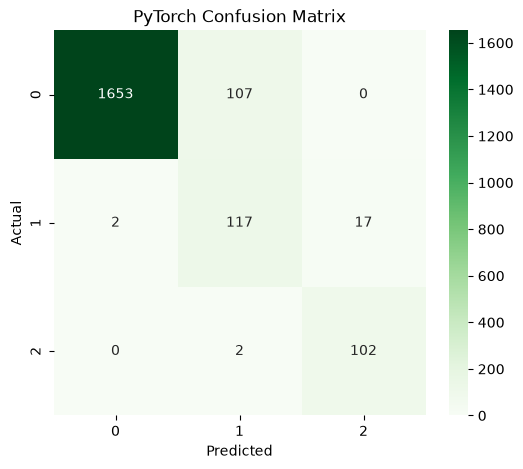

In [ ]:
pytorch_report, pytorch_f1, preds, targets = U.evaluate_model(model, test_loader, device, target_names)
print("PyTorch Performance on Test Set:")
print(classification_report(targets, preds, target_names=target_names, digits=4))
print(f"Macro F1-Score: {pytorch_f1:.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6,5))
U.plot_confusion_matrix(targets, preds, title='PyTorch Confusion Matrix', cmap='Greens', ax=ax)
plt.show()

### Learning Curves & Comparison
- **Loss curves**: Showing that validation loss improves steadily and then plateaus
- **Validation Macro F1**: The green curve shows the F1 improving over epochs. The red dashed line is the XGBoost baseline, which I expect PyTorch to surpass

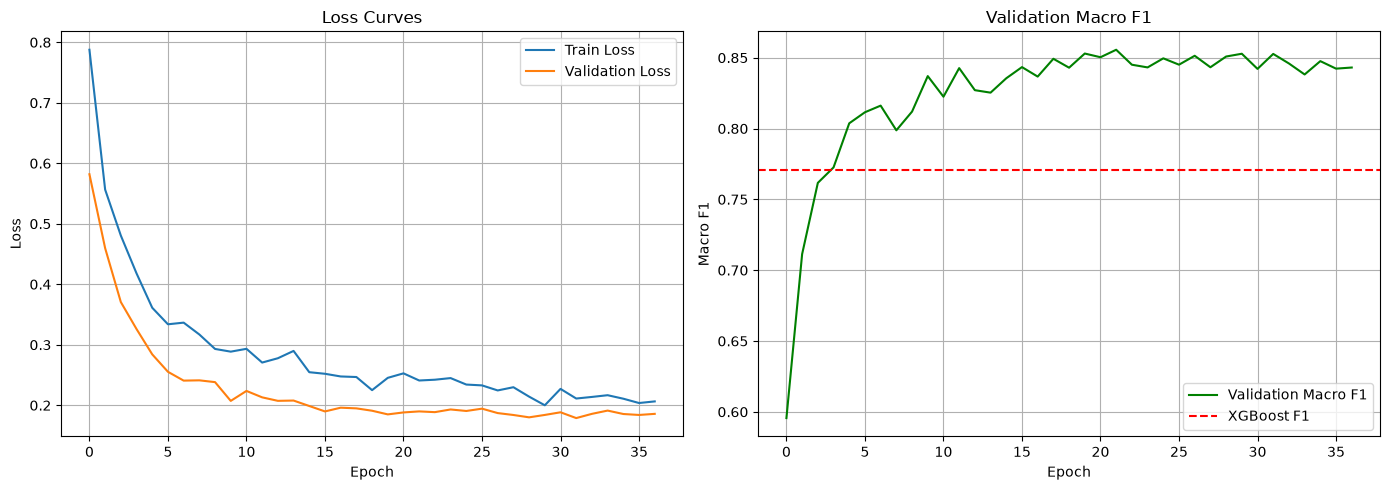

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14,5))
U.plot_loss_f1(train_losses, val_losses, val_f1s, xgb_baseline=xgb_macro_f1, axs=axs)
plt.tight_layout()
plt.show()

### Final Comparison
Printing the Macro F1 scores side‑by‑side. The improvement demonstrates the value of entity embeddings and weighted cross‑entropy over a traditional gradient‑boosting baseline.

In [ ]:
print("="*60)
print("FINAL COMPARISON")
print("="*60)
print(f"XGBoost  Macro F1: {xgb_macro_f1:.4f}")
print(f"PyTorch  Macro F1: {pytorch_f1:.4f}")
print(f"Improvement:       {pytorch_f1 - xgb_macro_f1:+.4f}")

FINAL COMPARISON
XGBoost  Macro F1: 0.7709
PyTorch  Macro F1: 0.8431
Improvement:       +0.0722
